In [44]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from svgpathtools import svg2paths

In [ ]:
import vtracer
vtracer.convert_image_to_svg_py("jpg/image.jpg", "svg/output.svg")

In [107]:
def plot_svg(file, inverted =True):
    paths, _ = svg2paths(file)
    color = "black"
    if inverted:
        plt.figure(facecolor="black")
        color = "white"
        
    for path in paths:
        x = []
        y = []
        
        for t in np.linspace(0,1,2000):
            z = path.point(t)
            x.append(z.real)
            y.append(-z.imag)
        plt.scatter(x,y,s=1, color = color)
        
    plt.axis("equal")
    plt.axis("off")
    plt.show()
    

Path(CubicBezier(start=(256+0j), control1=(114.843+0j), control2=(0.001+114.844j), end=(0.001+256.001j)),
     CubicBezier(start=(0.001+256.001j), control1=(0.001+397.156j), control2=(114.843+512j), end=(256+512j)),
     CubicBezier(start=(256+512j), control1=(397.157+512j), control2=(511.999+397.156j), end=(511.999+256.001j)),
     CubicBezier(start=(511.999+256.001j), control1=(511.999+114.844j), control2=(397.157+0j), end=(256+0j)),
     CubicBezier(start=(256+493.037j), control1=(125.297+493.037j), control2=(18.964+386.70399999999995j), end=(18.964+256.001j)),
     CubicBezier(start=(18.964+256.001j), control1=(18.964+125.296j), control2=(125.297+18.963j), end=(256+18.963j)),
     CubicBezier(start=(256+18.963j), control1=(386.703+18.963j), control2=(493.036+125.29599999999999j), end=(493.036+256.00100000000003j)),
     CubicBezier(start=(493.036+256.00100000000003j), control1=(493.036+386.704j), control2=(386.703+493.037j), end=(256+493.037j)))
Path(CubicBezier(start=(180.149+123.

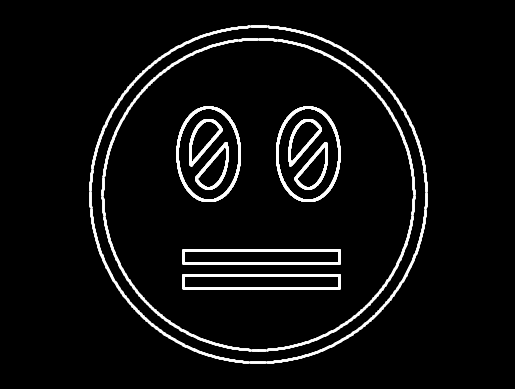

In [106]:
plot_svg("svg/face.svg", True)

In [47]:
def furier_projection(t_points, paths, n):
    t_max = len(paths)
    dt = t_max/(t_points-1)
    calc = 0.0
    omega = 2*np.pi/t_max
    t_global = 0.0
    
    for path in paths:
        for t in np.linspace(0,1,t_points): #t_max usually it will be one (svg standard)
            calc += path.point(t)*dt*np.exp(-1j*omega*n*t_global)
            t_global += dt
    return calc/t_max #essentialy this is cn

In [48]:
def abs_array(n):
    array = [0]
    for i in range(1,n+1):
        array.append(i)
        array.append(-1*i)
    return array
print(abs_array(3))

[0, 1, -1, 2, -2, 3, -3]


In [49]:
def furier(n_freq, t_points, paths):
    cn = []
    array = abs_array(n_freq)
    for n in array:
        cn.append(furier_projection(t_points, paths, n))
    return cn

In [108]:
def main(file, n_freq, t_points):
    paths, _ = svg2paths(file)
    cn = furier(n_freq, t_points,paths)
    t_max = len(paths)
    omega = 2*np.pi/t_max
    array = abs_array(n_freq)
    points = np.zeros(t_points, dtype=complex)
    
    for idx_global,t in enumerate(np.linspace(0,t_max,t_points)): #if tmax is 3s then there shoould be 3times more points
        point = complex(0,0)
        for idx,n in enumerate(array):  
            point += np.exp(1j*omega*n*t)*cn[idx]
            
        points[idx_global] = point
    x = points.real
    y = points.imag
    return x,y
    

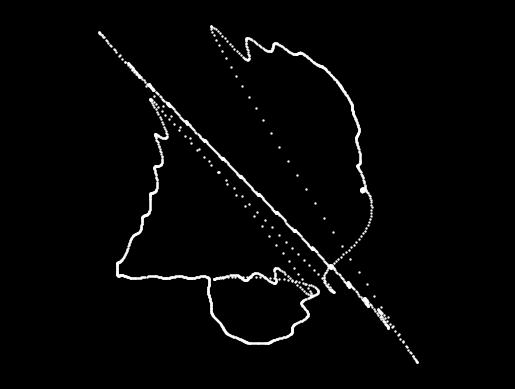

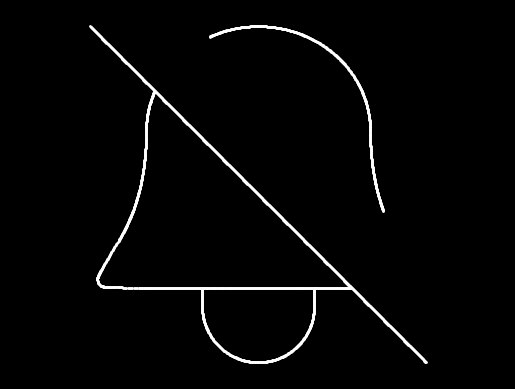

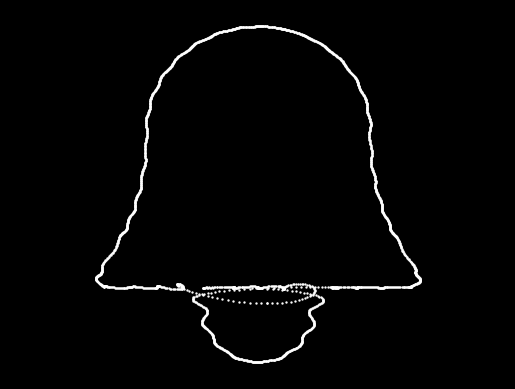

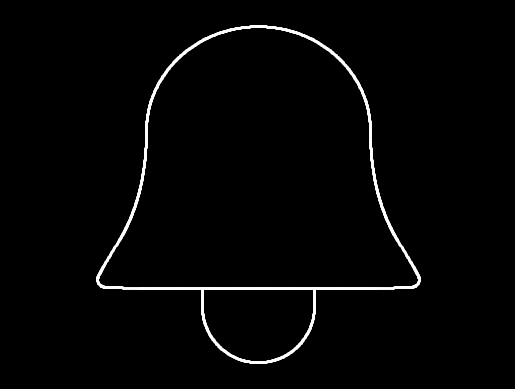

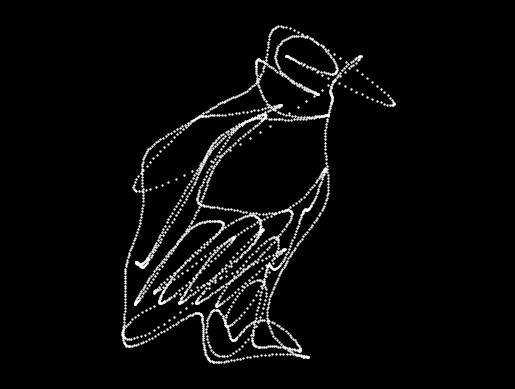

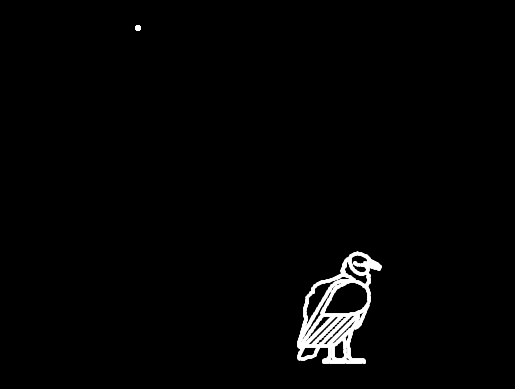

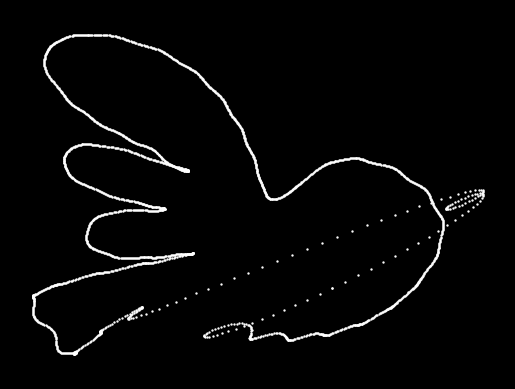

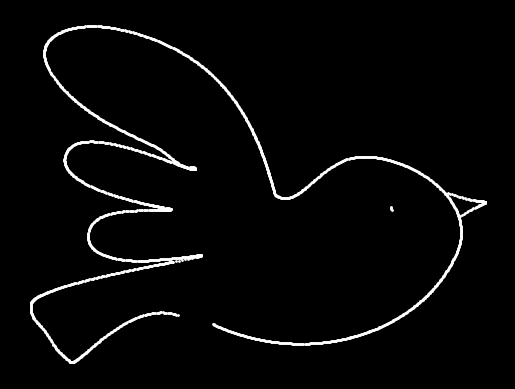

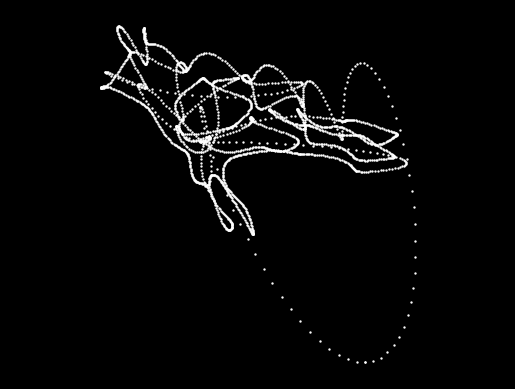

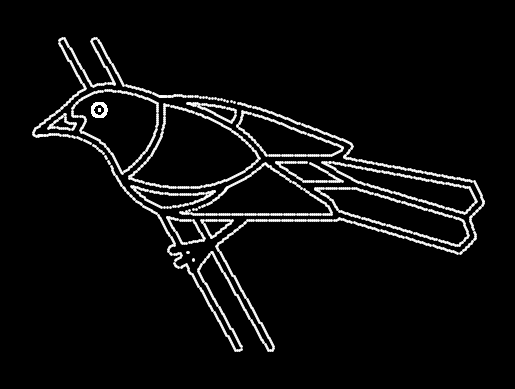

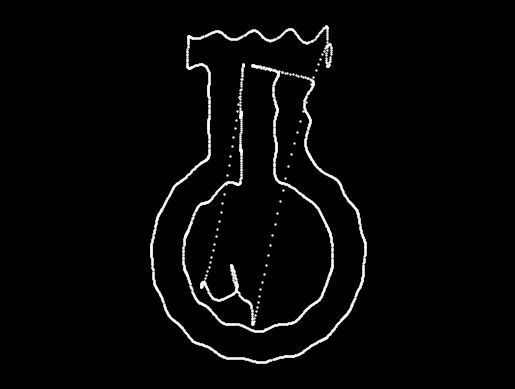

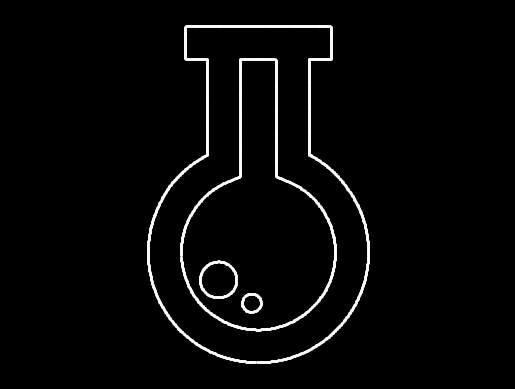

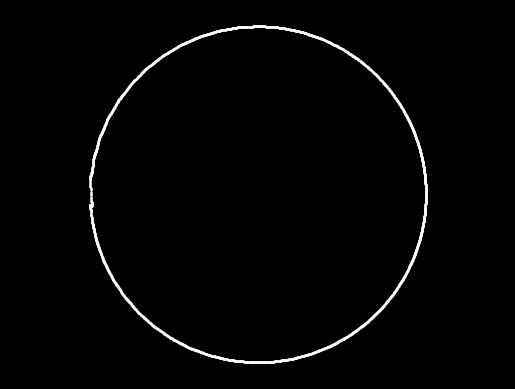

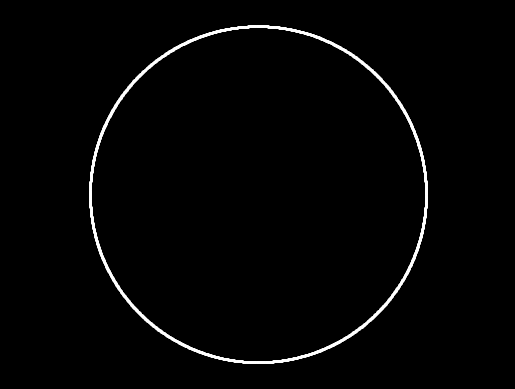

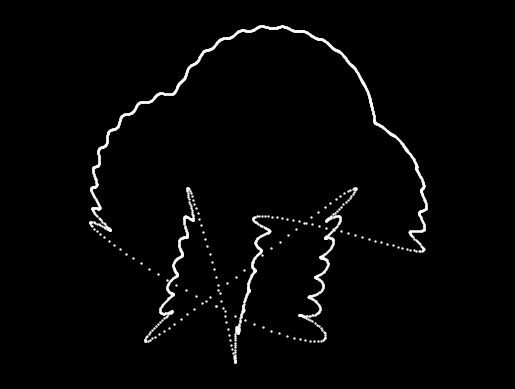

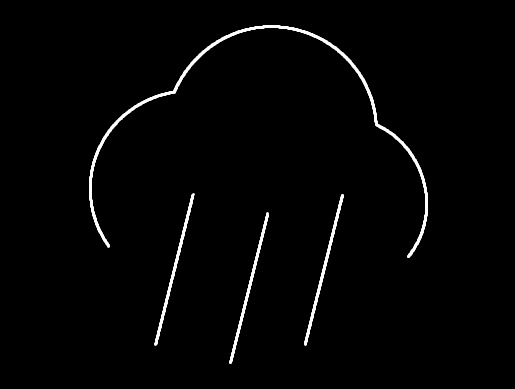

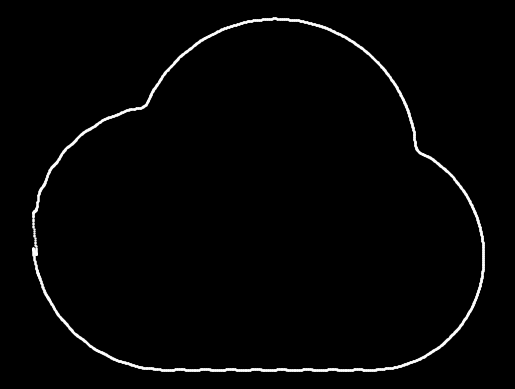

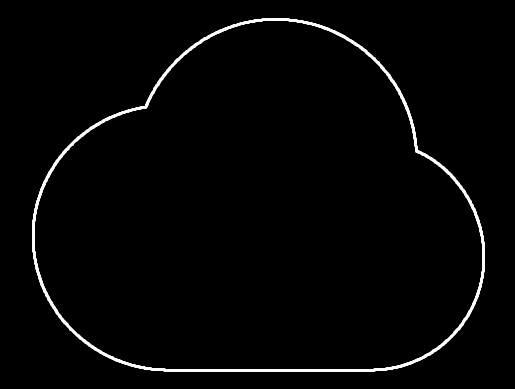

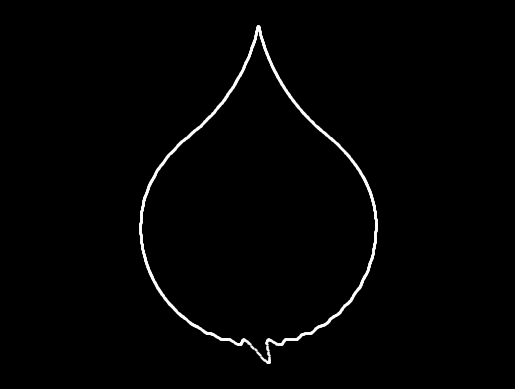

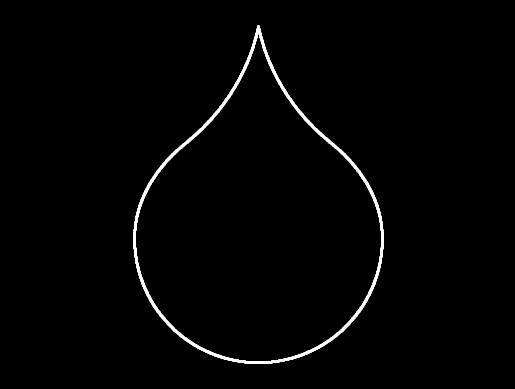

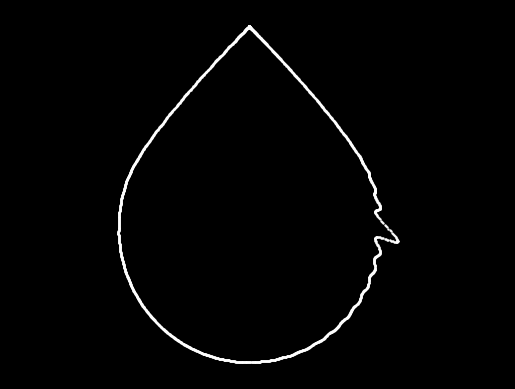

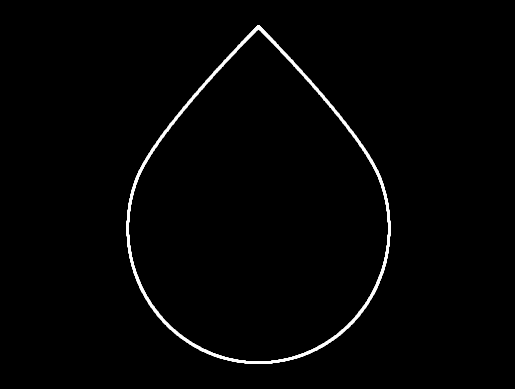

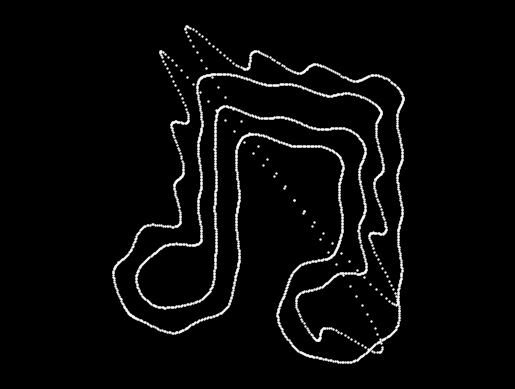

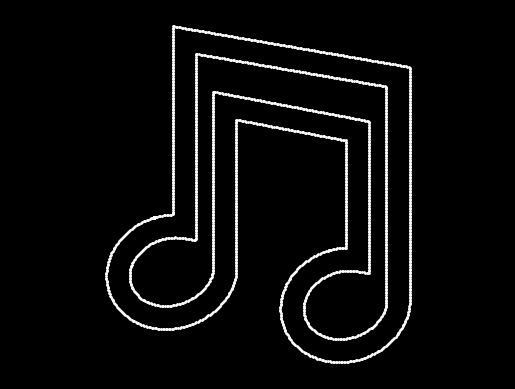

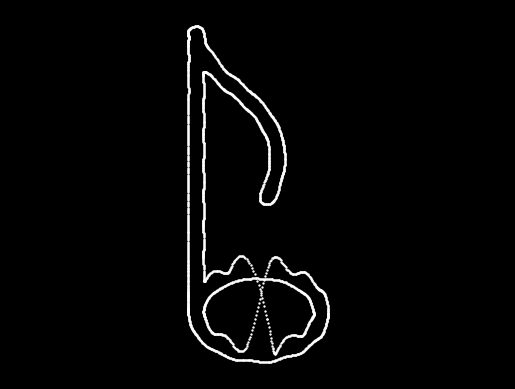

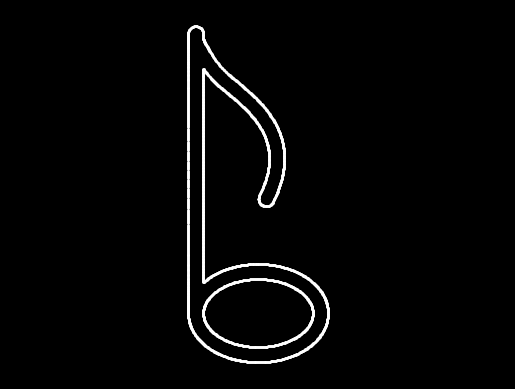

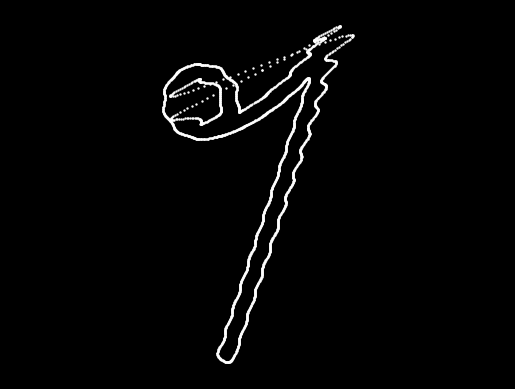

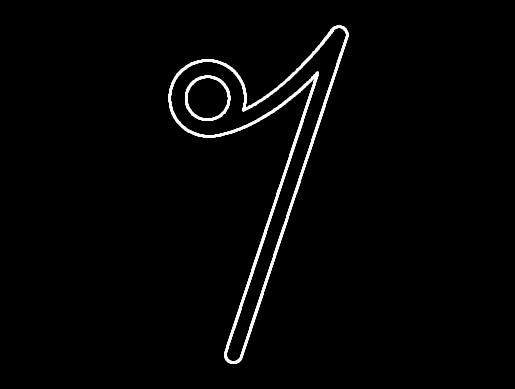

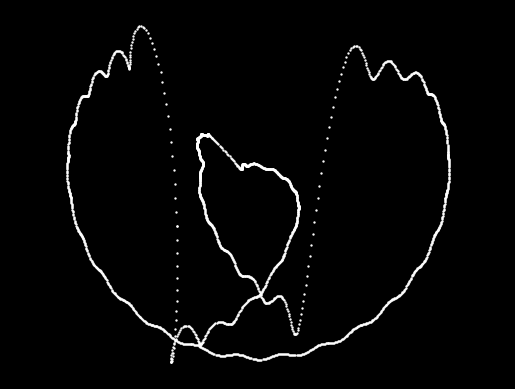

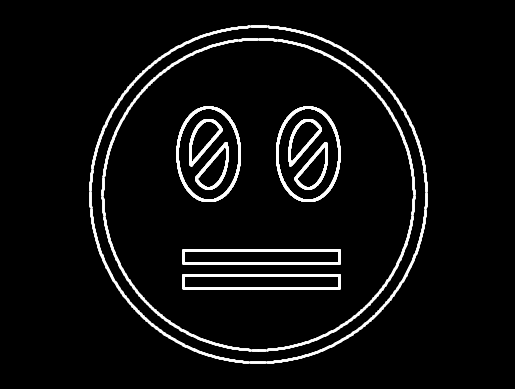

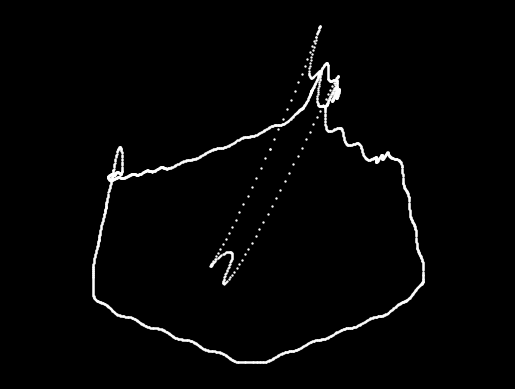

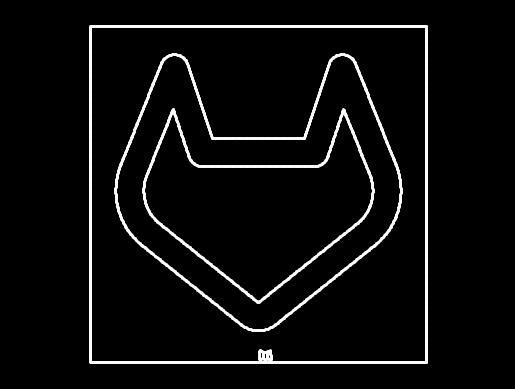

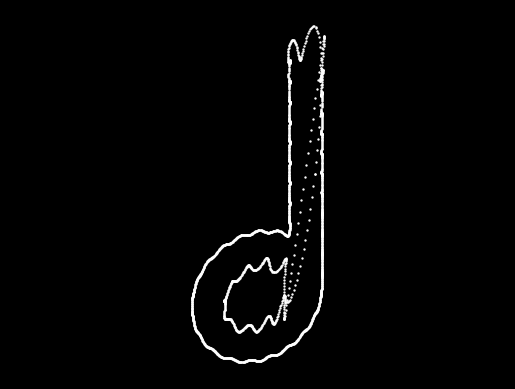

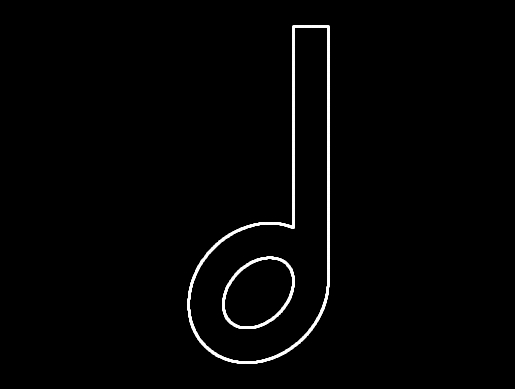

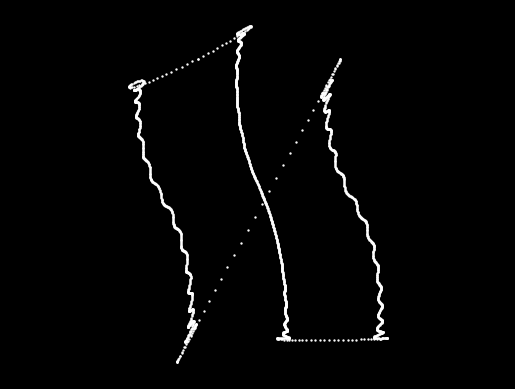

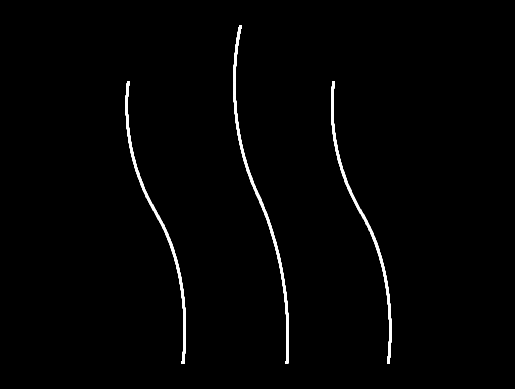

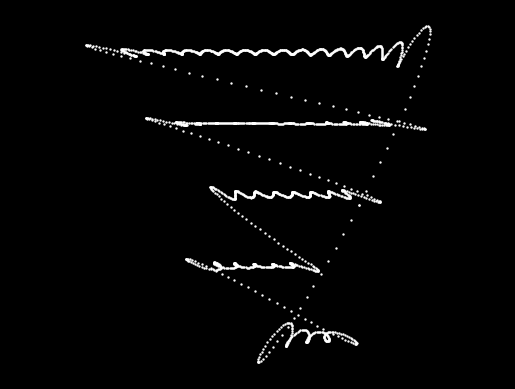

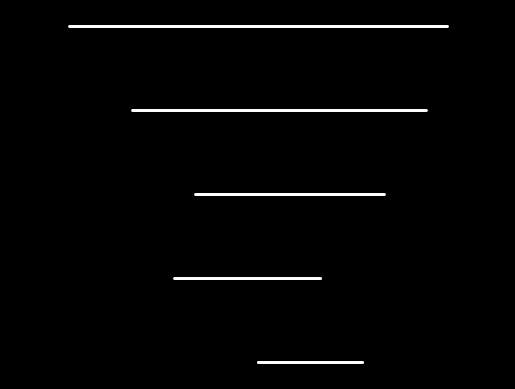

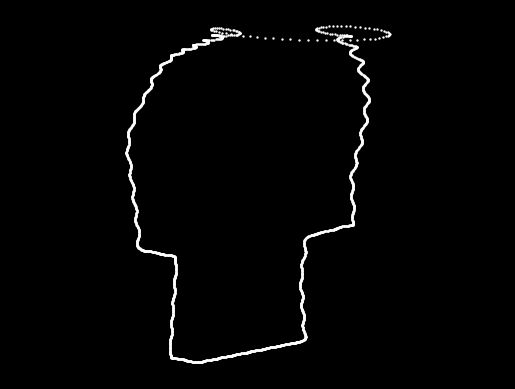

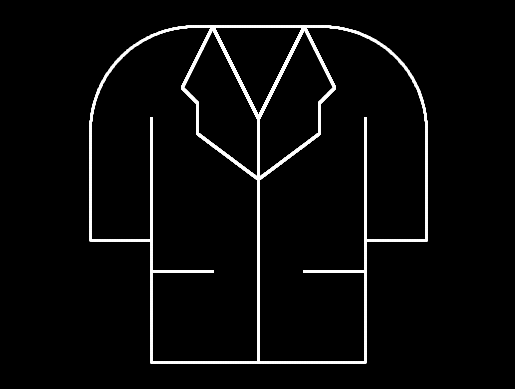

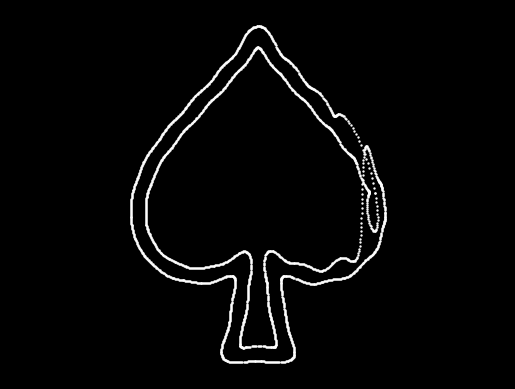

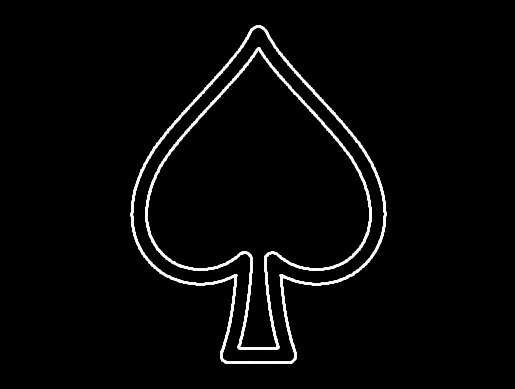

Skipped file svg/mlb.svg


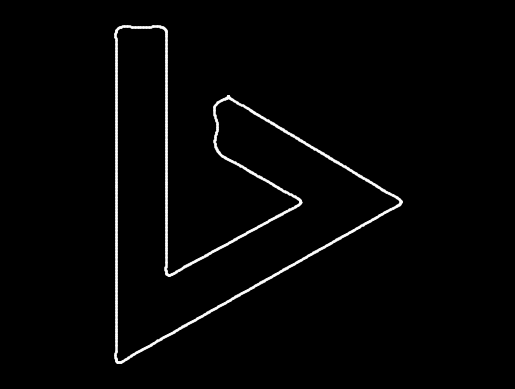

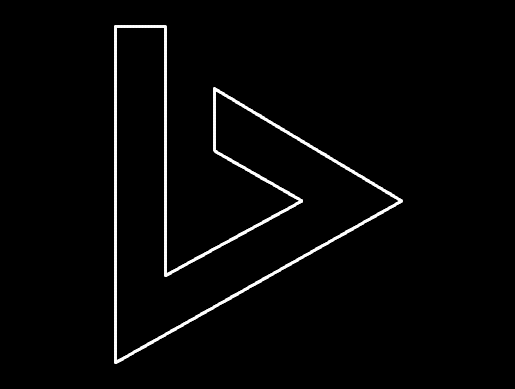

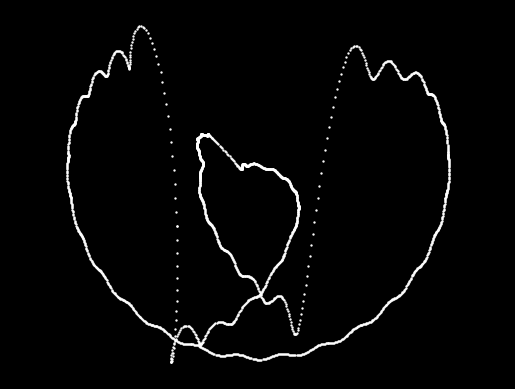

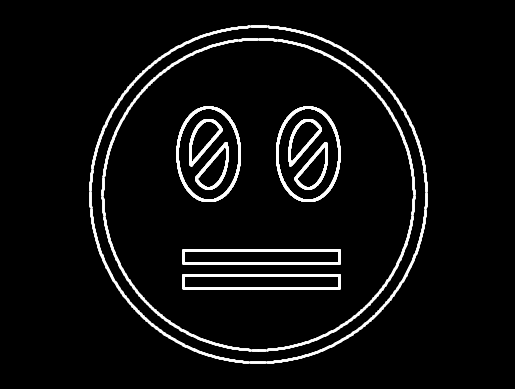

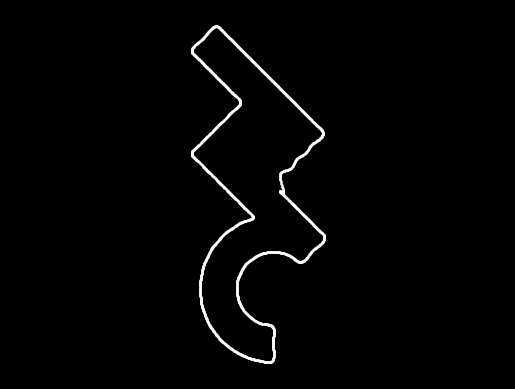

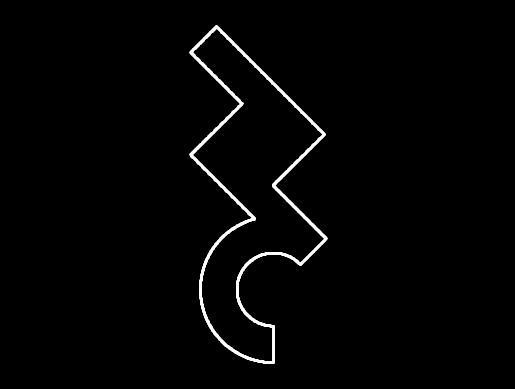

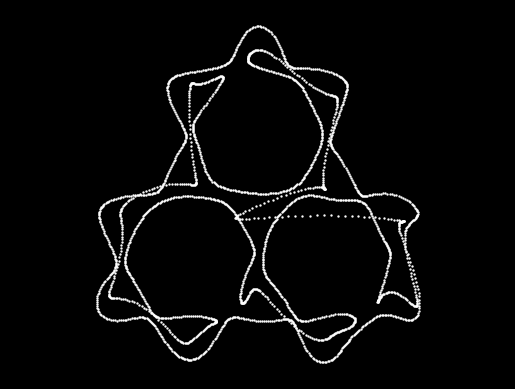

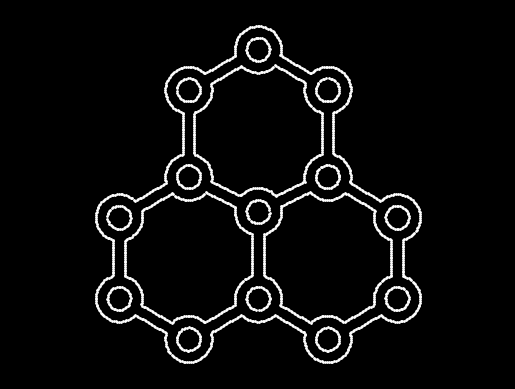

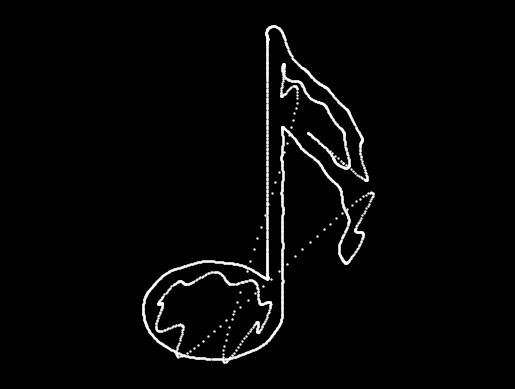

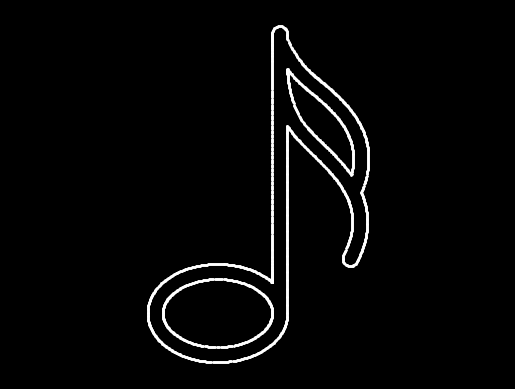

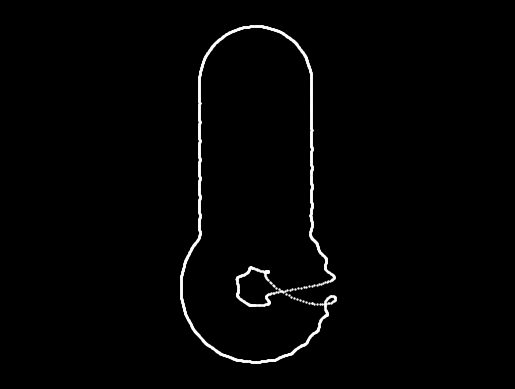

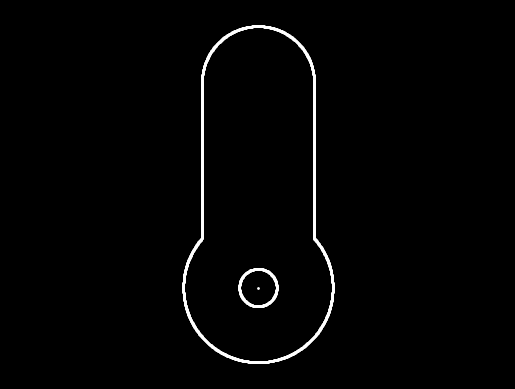

In [110]:
import os
import random
files = os.listdir("svg")

num = 5
rand = [random.randint(0, len(files)) for i in range(num)]

for file in files:
    try:
        file = "svg/"+file
        x,y = main(file, 50, 2000)
        y = -1*y
        plt.figure(facecolor="black")
        plt.scatter(x,y, color ="white",s=0.5)
        plt.axis("equal")
        plt.axis("off")
        plt.show()
        plot_svg(file,True)

    except Exception:
        print(f"Skipped file {file}")
